# Category LPP SPC

> Compute and visualize category-filtered LPP (Late Positive Potential) by study position.

The category LPP SPC plots mean LPP amplitude at each study position, filtered by item category. This reveals how neural encoding signals vary across the study list for different item types.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |
| `category_field` | Key providing item categories per study position |
| `lpp_field` | Key providing LPP values per study position |
| `contrast_name` | Legend title for contrasts |
| `category_values` | Category values to plot |
| `labels` | Legend labels per category |
| `color_cycle` | Colors for each curve |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.cat_lpp_spc import cat_lpp_spc, plot_cat_lpp_spc, category_lpp_values
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "Category LPP SPC"
data_path = "data/TalmiEEG.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['subject'] > 0"
category_field = "condition"
category_values = [1, 2]
lpp_field = "EarlyLPP"
labels = ["Negative", "Neutral"]
color_cycle = ["red", "black"]
contrast_name = "condition"

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

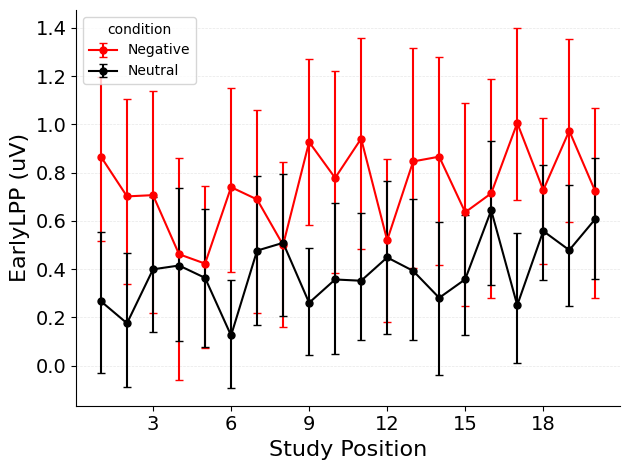

In [5]:
#| code-summary: Plot category-filtered LPP by study position
#| label: fig-cat-lpp-spc
#| fig-cap: "Category-filtered LPP by study position."
plot_cat_lpp_spc(data, trial_mask, category_field=category_field, category_values=category_values, lpp_field=lpp_field, labels=labels, color_cycle=color_cycle, contrast_name=contrast_name)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_cat_lpp_spc)

---

### plot_cat_lpp_spc

>      plot_cat_lpp_spc (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],ja
>                        xcmr.typing.RecallDataset], trial_masks:Union[Sequence[
>                        jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bool[Arr
>                        ay,'trial_count']], category_field:str,
>                        category_values:Sequence[int], lpp_field:str='LateLPP',
>                        color_cycle:Optional[list[str]]=None,
>                        labels:Optional[Sequence[str]]=None,
>                        contrast_name:Optional[str]=None,
>                        axis:Optional[matplotlib.axes._axes.Axes]=None,
>                        confidence_level:float=0.95)

*Plot category-filtered LPP curves by study position.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| category_field | str |  | Key providing item categories per study position. |
| category_values | Sequence |  | Categories to plot. |
| lpp_field | str | LateLPP | Key providing LPP values per study position. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the category LPP plot.** |

In [7]:
#| echo: false
show_doc(cat_lpp_spc)

---

### cat_lpp_spc

>      cat_lpp_spc (dataset:jaxcmr.typing.RecallDataset, category_field:str,
>                   category_value:int, lpp_field:str='EarlyLPP')

*Category-filtered mean LPP by study position.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with per-item LPP metadata. |
| category_field | str |  | Key providing item categories per study position. |
| category_value | int |  | Category to filter on. |
| lpp_field | str | EarlyLPP | Key providing LPP values per study position. |
| **Returns** | **Float[Array, 'study_positions']** |  | **Mean LPP at each position for the category.** |

In [8]:
#| echo: false
show_doc(category_lpp_values)

---

### category_lpp_values

>      category_lpp_values
>                           (lpp:jaxtyping.Float[Array,'trial_countstudy_positio
>                           ns'], categories:jaxtyping.Integer[Array,'trial_coun
>                           tstudy_positions'], category_value:int)

*Returns mean LPP per position restricted to a category.*